##Porównanie wydajności CPU i GPU w przetwarzaniu obrazów

Celem projektu było stworzenie i porównanie implementacji algorytmów przetwarzania obrazu wykonywanych na procesorze CPU oraz GPU z wykorzystaniem technologii CUDA i biblioteki Numba.

Wykorzystane algorytmy:
- Mean Filter
- Gaussian Blur
- Sobel Edge Detection

In [ ]:
!pip install numba

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numba import (cuda, njit, prange, float32)
from time import perf_counter_ns

In [ ]:
# wczytanie obrazu
from google.colab import files
uploaded = files.upload()

Saving house.jpg to house (1).jpg


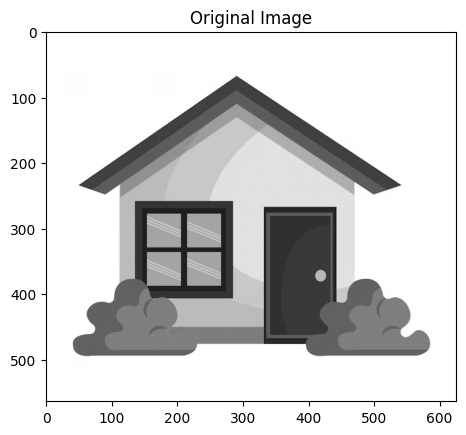

In [ ]:
# Konwersja do grayscale

img = Image.open("house.jpg").convert("L")

img = np.array(img).astype(np.float32) / 255.0

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.show()

In [ ]:
# CPU Mean Filter
@njit(parallel=True)
def mean_filter_cpu(image):

    rows, cols = image.shape
    result = np.zeros_like(image)

    for i in prange(1, rows - 1):
        for j in range(1, cols - 1):
            acc = 0.0
            for r in range(-1, 2):
                for c in range(-1, 2):
                    acc += image[i + r, j + c]
            result[i, j] = acc / 9.0

    return result

In [ ]:
# GPU Mean Filter
@cuda.jit
def mean_filter_gpu(image, result):

    row, col = cuda.grid(2)
    rows, cols = image.shape

    if 0 < row < rows - 1 and 0 < col < cols - 1:
        acc = 0.0

        for r in range(-1, 2):
            for c in range(-1, 2):
                acc += image[row + r, col + c]

        result[row, col] = acc / 9.0

In [ ]:
# CPU Gaussian Blur
@njit(parallel=True)
def gaussian_blur_cpu(image):

    rows, cols = image.shape
    result = np.zeros_like(image)

    kernel = np.array([
        [1,2,1],
        [2,4,2],
        [1,2,1]
    ], dtype=np.float32) / 16.0

    for i in prange(1, rows-1):
        for j in range(1, cols-1):
            acc = 0.0
            for r in range(-1,2):
                for c in range(-1,2):
                    acc += (image[i+r, j+c] * kernel[r+1, c+1])

            result[i,j] = acc

    return result

In [ ]:
# GPU Gaussian Blur
@cuda.jit
def gaussian_blur_gpu(image, result):

    row, col = cuda.grid(2)
    rows, cols = image.shape

    if 0 < row < rows-1 and 0 < col < cols-1:

        acc = 0.0

        acc += image[row-1,col-1] * 1
        acc += image[row-1,col]   * 2
        acc += image[row-1,col+1] * 1

        acc += image[row,col-1] * 2
        acc += image[row,col]   * 4
        acc += image[row,col+1] * 2

        acc += image[row+1,col-1] * 1
        acc += image[row+1,col]   * 2
        acc += image[row+1,col+1] * 1

        result[row,col] = acc / 16.0

In [ ]:
# Sobel edge detection CPU
@njit(parallel=True)
def sobel_cpu(image):

    rows, cols = image.shape
    result = np.zeros_like(image)

    Gx = np.array([
        [-1,0,1],
        [-2,0,2],
        [-1,0,1]
    ], dtype=np.float32)

    Gy = np.array([
        [-1,-2,-1],
        [0,0,0],
        [1,2,1]
    ], dtype=np.float32)

    for i in prange(1, rows-1):
        for j in range(1, cols-1):
            sx = 0.0
            sy = 0.0
            for r in range(-1,2):
                for c in range(-1,2):
                    pixel = image[i+r, j+c]

                    sx += pixel * Gx[r+1,c+1]
                    sy += pixel * Gy[r+1,c+1]

            result[i,j] = np.sqrt(sx*sx + sy*sy)

    return result

In [ ]:
# GPU
@cuda.jit
def sobel_gpu(image, result):

    row, col = cuda.grid(2)
    rows, cols = image.shape

    if 0 < row < rows-1 and 0 < col < cols-1:

        sx = 0.0
        sy = 0.0

        # Gx
        sx += -1 * image[row-1,col-1]
        sx +=  0 * image[row-1,col]
        sx +=  1 * image[row-1,col+1]

        sx += -2 * image[row,col-1]
        sx +=  0 * image[row,col]
        sx +=  2 * image[row,col+1]

        sx += -1 * image[row+1,col-1]
        sx +=  0 * image[row+1,col]
        sx +=  1 * image[row+1,col+1]

        # Gy
        sy += -1 * image[row-1,col-1]
        sy += -2 * image[row-1,col]
        sy += -1 * image[row-1,col+1]

        sy +=  0 * image[row,col-1]
        sy +=  0 * image[row,col]
        sy +=  0 * image[row,col+1]

        sy +=  1 * image[row+1,col-1]
        sy +=  2 * image[row+1,col]
        sy +=  1 * image[row+1,col+1]

        result[row,col] = (sx*sx + sy*sy)**0.5

In [ ]:
# Cuda config

threads = (16,16)

blocks = ((img.shape[1] + 15)//16, (img.shape[0] + 15)//16)

In [ ]:
# Mean Filter benchmark
print("Mean filter")

# CPU
dummy = np.random.rand(32,32).astype(np.float32)
mean_filter_cpu(dummy)

t0 = perf_counter_ns()

mean_cpu = mean_filter_cpu(img)

t1 = perf_counter_ns()

mean_cpu_time = (t1 - t0) / 1e6

# GPU
d_img = cuda.to_device(img)

d_res = cuda.device_array_like(img)

mean_filter_gpu[blocks, threads](d_img, d_res)
cuda.synchronize()

start = cuda.event()
end = cuda.event()

start.record()

mean_filter_gpu[blocks, threads](d_img, d_res)

end.record()
end.synchronize()

mean_gpu_time = cuda.event_elapsed_time(start, end)

mean_gpu = d_res.copy_to_host()

print(f"CPU: {mean_cpu_time:.3f} ms")
print(f"GPU: {mean_gpu_time:.3f} ms")

Mean filter
CPU: 0.843 ms
GPU: 0.375 ms


In [ ]:
# Gaussian blur benchmark

print("gaussian blur")

gaussian_blur_cpu(dummy)
t0 = perf_counter_ns()

gaussian_cpu = gaussian_blur_cpu(img)

t1 = perf_counter_ns()

gaussian_cpu_time = (t1 - t0) / 1e6

d_res_gaussian = cuda.device_array_like(img)

gaussian_blur_gpu[blocks, threads](d_img, d_res_gaussian)
cuda.synchronize()

start = cuda.event()
end = cuda.event()

start.record()

gaussian_blur_gpu[blocks, threads](d_img, d_res_gaussian)

end.record()
end.synchronize()

gaussian_gpu_time = cuda.event_elapsed_time(start, end)

gaussian_gpu = d_res_gaussian.copy_to_host()

print(f"CPU: {gaussian_cpu_time:.3f} ms")
print(f"GPU: {gaussian_gpu_time:.3f} ms")

gaussian blur
CPU: 0.757 ms
GPU: 0.315 ms


In [ ]:
# Sobel benchmark
print("Sobel edge detection")

sobel_cpu(dummy)

t0 = perf_counter_ns()

sobel_cpu_res = sobel_cpu(img)

t1 = perf_counter_ns()

sobel_cpu_time = (t1 - t0) / 1e6

d_res_sobel = cuda.device_array_like(img)

sobel_gpu[blocks, threads](d_img, d_res_sobel)
cuda.synchronize()

start = cuda.event()
end = cuda.event()

start.record()

sobel_gpu[blocks, threads](d_img, d_res_sobel)

end.record()
end.synchronize()

sobel_gpu_time = cuda.event_elapsed_time(start, end)

sobel_gpu_res = d_res_sobel.copy_to_host()

print(f"CPU: {sobel_cpu_time:.3f} ms")
print(f"GPU: {sobel_gpu_time:.3f} ms")

Sobel edge detection
CPU: 1.522 ms
GPU: 1.149 ms


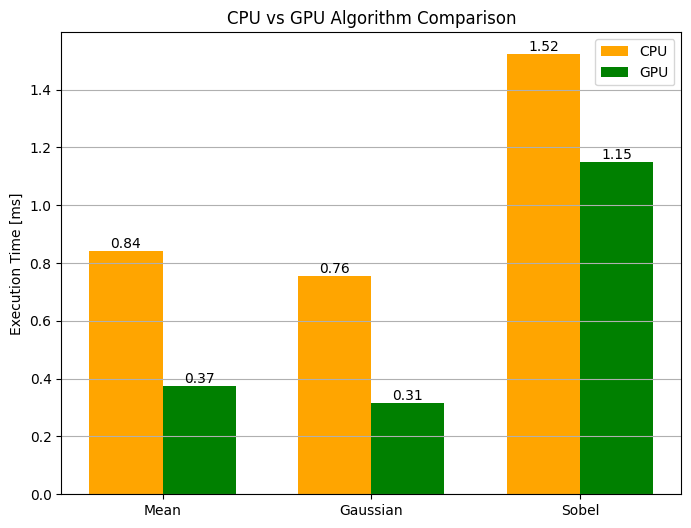

In [ ]:
algorithms = [
    "Mean",
    "Gaussian",
    "Sobel"
]

cpu_alg_times = [
    mean_cpu_time,
    gaussian_cpu_time,
    sobel_cpu_time
]

gpu_alg_times = [
    mean_gpu_time,
    gaussian_gpu_time,
    sobel_gpu_time
]

x = np.arange(len(algorithms))

width = 0.35

plt.figure(figsize=(8,6))

bars1 = plt.bar(x - width/2, cpu_alg_times,width,label='CPU', color='orange')
bars2 = plt.bar(x + width/2, gpu_alg_times, width, label='GPU', color='green')

plt.xticks(x, algorithms)
plt.ylabel("Execution Time [ms]")
plt.title("CPU vs GPU Algorithm Comparison")
plt.legend()

# liczby nad słupkami
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}",
            ha='center',
            va='bottom',
        )

plt.grid(axis='y')
plt.show()

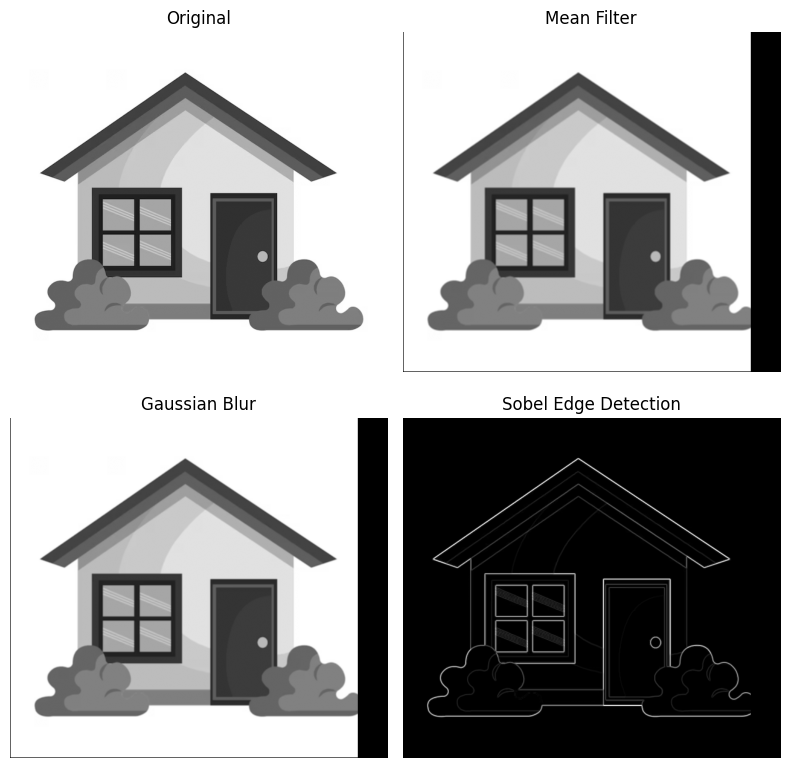

In [ ]:
plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(mean_gpu, cmap='gray')
plt.title("Mean Filter")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(gaussian_gpu, cmap='gray')
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(sobel_gpu_res, cmap='gray')
plt.title("Sobel Edge Detection")
plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
print("Porównanie czasowe z podanymi rozmiarami")

sizes = [256, 512, 1024, 2048, 4096]

cpu_times = []
gpu_times = []

dummy = np.random.rand(32,32).astype(np.float32)
gaussian_blur_cpu(dummy)

for size in sizes:

    img_test = np.random.rand(size, size).astype(np.float32)

    # CPU
    t0 = perf_counter_ns()

    gaussian_blur_cpu(img_test)

    t1 = perf_counter_ns()

    cpu_ms = (t1 - t0) / 1e6

    # GPU
    d_img = cuda.to_device(img_test)

    d_res = cuda.device_array_like(img_test)

    threads = (16,16)

    blocks = (
        (size + 15)//16,
        (size + 15)//16
    )

    gaussian_blur_gpu[blocks, threads](d_img, d_res)
    cuda.synchronize()

    start = cuda.event()
    end = cuda.event()

    start.record()

    gaussian_blur_gpu[blocks, threads](d_img, d_res)

    end.record()
    end.synchronize()

    gpu_ms = cuda.event_elapsed_time(start, end)

    cpu_times.append(cpu_ms)
    gpu_times.append(gpu_ms)

    print(f"\n{size}x{size}")
    print(f"CPU: {cpu_ms:.2f} ms")
    print(f"GPU: {gpu_ms:.2f} ms")

Porównanie czasowe z podanymi rozmiarami

256x256
CPU: 0.61 ms
GPU: 0.11 ms

512x512
CPU: 0.42 ms
GPU: 0.21 ms

1024x1024
CPU: 1.75 ms
GPU: 0.59 ms

2048x2048
CPU: 12.81 ms
GPU: 2.10 ms

4096x4096
CPU: 58.49 ms
GPU: 8.13 ms


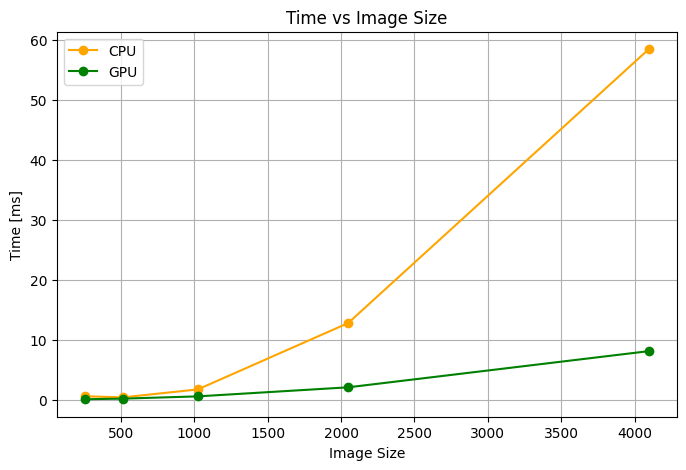

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(sizes, cpu_times, marker='o', label='CPU', color='orange')
plt.plot(sizes, gpu_times, marker='o', label='GPU', color='green')
plt.xlabel("Image Size")
plt.ylabel("Time [ms]")
plt.title("Time vs Image Size")
plt.legend()
plt.grid(True)
plt.show()

##Wnioski
- Przeprowadzone testy pokazują, że wraz ze wzrostem rozmiaru obrazu rośnie przewaga GPU nad CPU.
- Dla małych obrazów, takich jak 256×256, 512×512 różnica pomiędzy CPU i GPU jest stosunkowo niewielka. Wynika to z narzutu związanego z uruchomieniem kernela CUDA oraz transferem danych do pamięci GPU.
- W przypadku większych obrazów przewaga GPU staje się znacznie bardziej widoczna dla obrazu 4096×4096.

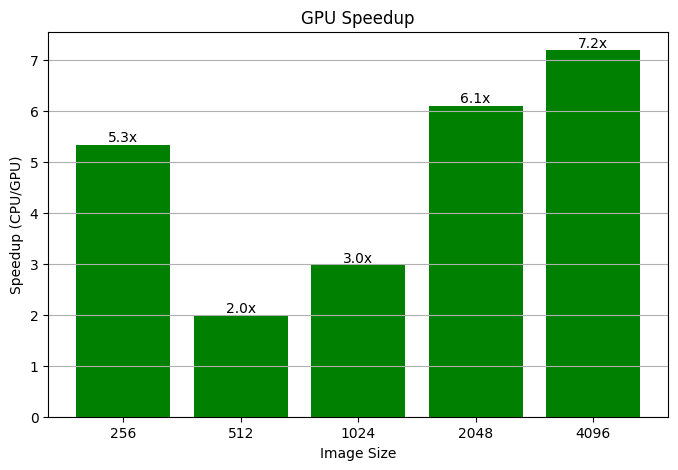

In [ ]:
speedups = []

for cpu, gpu in zip(cpu_times, gpu_times):
    speedups.append(cpu / gpu)

plt.figure(figsize=(8,5))

bars = plt.bar([str(s) for s in sizes], speedups, color='green')
plt.xlabel("Image Size")
plt.ylabel("Speedup (CPU/GPU)")

plt.title("GPU Speedup")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}x",
        ha='center',
        va='bottom'
    )

plt.grid(axis='y')
plt.show()

##Wnioski
- Na podstawie uzyskanych wyników można zauważyć, że wraz ze wzrostem rozdzielczości obrazu rośnie efektywność GPU, w szczególności dla obrazu o rozmiarze 4096×4096, gdzie
przyspieszenie osiągnęło około 7.2x względem CPU.
- Dla małych obrazów przyspieszenie jest mniejsze, ponieważ narzut związany z uruchomieniem kernela CUDA i transfer danych między CPU i GPU stanowią istotną część całkowitego czasu wykonania.